# Real Market Data and De-Time Feature Factory

This notebook downloads real close prices, audits them, and computes walk-forward De-Time features. It intentionally stops if real market data is not available.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
for path in [ROOT / "src", ROOT / "examples"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from quant_trading.data import fetch_yahoo_prices, fetch_yahoo_ohlcv, data_audit_report, DEFAULT_UNIVERSES
from quant_trading.features import decompose_one_series, walkforward_decompose, build_feature_table
from quant_trading.signals import (
    trend_pullback_signals,
    residual_mean_reversion_signals,
    turtle_donchian_signals,
    pair_trading_weights,
    cross_sectional_rotation_weights,
    residual_stress_filter,
)
from quant_trading.backtest import backtest_weights, backtest_long_short_signals, summarize_returns

In [2]:
tickers = ["AAPL", "MSFT", "NVDA", "005930.KS", "000660.KS", "BTC-USD", "ETH-USD"]
prices = fetch_yahoo_prices(
    tickers,
    start="2018-01-01",
    interval="1d",
    cache_dir=ROOT / "examples" / "quant_trading" / "data" / "cache",
    min_observations=500,
)
prices.tail()

,AAPL,MSFT,NVDA,005930.KS,000660.KS,BTC-USD,ETH-USD
Date,,,,,,,
2026-05-18,297.839996,422.624664,222.320007,281000.0,1840000.0,76954.171875,2128.516113
2026-05-19,298.970001,416.517883,220.610001,275500.0,1745000.0,76750.906250,2109.963867
2026-05-20,302.250000,420.149994,223.470001,276000.0,1745000.0,77457.773438,2126.983398
2026-05-21,304.989990,419.089996,219.509995,299500.0,1940000.0,77539.171875,2131.410645
2026-05-22,311.364990,419.411713,217.639999,299500.0,1940000.0,76710.062500,2116.919922


In [3]:
audit = data_audit_report(prices)
audit

,ticker,first_timestamp,last_timestamp,observations,missing_ratio,min_price,max_price
0,AAPL,2018-01-01,2026-05-22,3064,0.0,33.737000,3.113650e+02
1,MSFT,2018-01-01,2026-05-22,3064,0.0,77.839211,5.386585e+02
2,NVDA,2018-01-01,2026-05-22,3064,0.0,3.150397,2.357400e+02
3,005930.KS,2018-01-01,2026-05-22,3064,0.0,31213.435547,2.995000e+05
4,000660.KS,2018-01-01,2026-05-22,3064,0.0,53071.496094,1.976000e+06
5,BTC-USD,2018-01-01,2026-05-22,3064,0.0,3236.761719,1.247525e+05
6,ETH-USD,2018-01-01,2026-05-22,3064,0.0,84.308296,4.831349e+03


## Visualization: data audit coverage

This chart exposes the real-data coverage and missingness before decomposition starts.

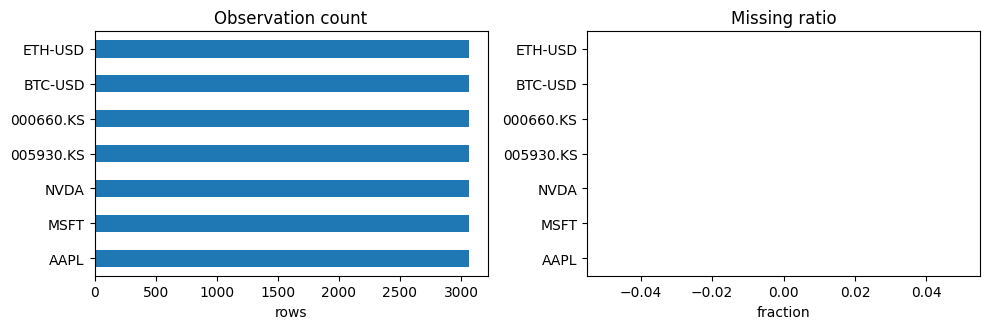

In [4]:
audit_plot = audit.set_index("ticker")[["observations", "missing_ratio"]].copy()
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
audit_plot["observations"].sort_values().plot(kind="barh", ax=axes[0], color="tab:blue", title="Observation count")
audit_plot["missing_ratio"].sort_values().plot(kind="barh", ax=axes[1], color="tab:orange", title="Missing ratio")
axes[0].set_xlabel("rows")
axes[1].set_xlabel("fraction")
for ax in axes:
    ax.set_ylabel("")
plt.tight_layout()
plt.show()


## Decompose one asset first

The output frame includes the original price, transformed price, trend, cycle/seasonal component, residual, and standardized features.

In [5]:
frame = decompose_one_series(prices["AAPL"], method="STL", period=63)
frame[["price", "trend", "season", "residual", "trend_slope", "residual_z"]].tail()

,price,trend,season,residual,trend_slope,residual_z
Date,,,,,,
2026-05-18,297.839996,5.646727,0.019480,0.030349,0.001765,1.583226
2026-05-19,298.970001,5.648524,0.024441,0.027379,0.001776,1.413101
2026-05-20,302.250000,5.650331,0.026464,0.034460,0.001786,1.644990
2026-05-21,304.989990,5.652148,0.027196,0.040935,0.001796,1.847474
2026-05-22,311.364990,5.653975,0.034810,0.052181,0.001807,2.231897


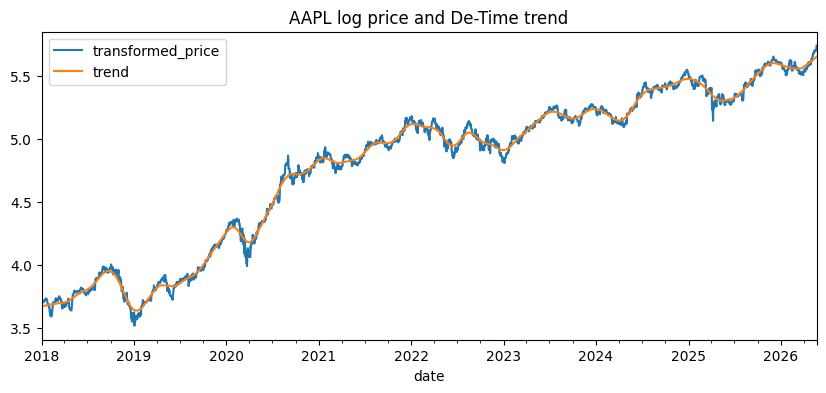

In [6]:
ax = frame[["transformed_price", "trend"]].plot(figsize=(10, 4), title="AAPL log price and De-Time trend")
ax.set_xlabel("date")
plt.show()

## Visualization: AAPL decomposition diagnostics

The diagnostic view separates trend gap, seasonal z-score, and residual z-score so the signal ingredients are visible.

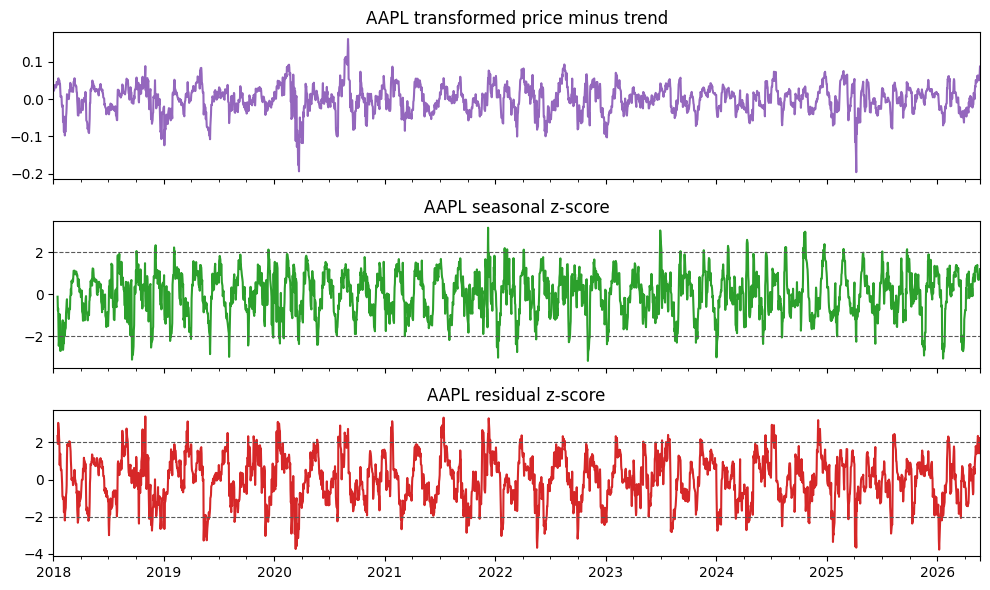

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
frame["trend_gap"].plot(ax=axes[0], color="tab:purple", title="AAPL transformed price minus trend")
frame["season_z"].plot(ax=axes[1], color="tab:green", title="AAPL seasonal z-score")
frame["residual_z"].plot(ax=axes[2], color="tab:red", title="AAPL residual z-score")
for ax in axes[1:]:
    ax.axhline(2.0, color="0.35", linestyle="--", linewidth=0.8)
    ax.axhline(-2.0, color="0.35", linestyle="--", linewidth=0.8)
for ax in axes:
    ax.set_xlabel("")
plt.tight_layout()
plt.show()


## Walk-forward feature factory

This step recomputes De-Time on rolling historical windows and keeps only the last row of each window. This avoids full-sample decomposition leakage.

In [8]:
features = walkforward_decompose(
    prices[["AAPL", "MSFT", "NVDA"]],
    method="STL",
    period=63,
    train_window=252,
    step=21,
)
feature_table = build_feature_table(prices[["AAPL", "MSFT", "NVDA"]], features)
feature_table.tail()

realized_vol_20                     reconstruction_error            \
                      AAPL      MSFT      NVDA                 AAPL MSFT NVDA   
Date                                                                            
2026-05-18        0.172189  0.216533  0.379711                  0.0  0.0  0.0   
2026-05-19        0.170428  0.218846  0.374098                  0.0  0.0  0.0   
2026-05-20        0.171559  0.169817  0.329438                  0.0  0.0  0.0   
2026-05-21        0.141926  0.161623  0.337332                  0.0  0.0  0.0   
2026-05-22        0.151935  0.161602  0.340286                  0.0  0.0  0.0   

            residual                     residual_abs_z  ...     trend  \
                AAPL      MSFT      NVDA           AAPL  ...      NVDA   
Date                                                     ...             
2026-05-18  0.010219  0.018871  0.023964       1.064182  ...  5.234949   
2026-05-19  0.010219  0.018871  0.023964       1.064182  ...  5.234949   
2026-05-20  0.010219  0.018871  0.023964       1.064182  ...  5.234949   
2026-05-21  0.010219  0.018871  0.023964       1.064182  ...  5.234949   
2026-05-22  0.010219  0.018871  0.023964       1.064182  ...  5.234949   

           trend_gap                     trend_slope                      \
                AAPL      MSFT      NVDA        AAPL      MSFT      NVDA   
Date                                                                       
2026-05-18  0.081935  0.054285  0.055588   -0.000111  0.000007  0.000577   
2026-05-19  0.081935  0.054285  0.055588   -0.000111  0.000007  0.000577   
2026-05-20  0.081935  0.054285  0.055588   -0.000111  0.000007  0.000577   
2026-05-21  0.081935  0.054285  0.055588   -0.000111  0.000007  0.000577   
2026-05-22  0.081935  0.054285  0.055588   -0.000111  0.000007  0.000577   

           trend_strength                      
                     AAPL      MSFT      NVDA  
Date                                           
2026-05-18      -0.010247  0.000508  0.024121  
2026-05-19      -0.010353  0.000503  0.024483  
2026-05-20      -0.010284  0.000648  0.027802  
2026-05-21      -0.012432  0.000680  0.027151  
2026-05-22      -0.011613  0.000681  0.026915  

[5 rows x 39 columns]

## Visualization: latest walk-forward features

The latest feature snapshot shows how trend strength, residual state, and reconstruction error differ across assets.

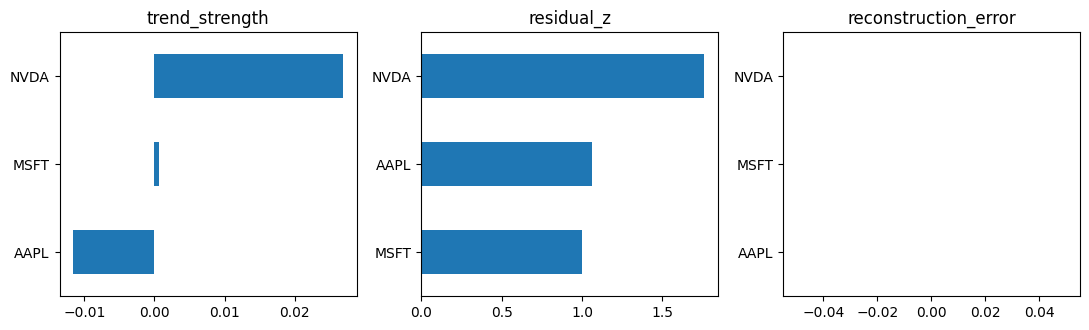

In [9]:
latest_feature_slice = feature_table.dropna(how="all").iloc[-1].unstack(0)
metric_cols = ["trend_strength", "residual_z", "reconstruction_error"]
fig, axes = plt.subplots(1, len(metric_cols), figsize=(11, 3.4))
for ax, metric in zip(axes, metric_cols):
    latest_feature_slice[metric].sort_values().plot(kind="barh", ax=ax, title=metric)
    ax.set_ylabel("")
plt.tight_layout()
plt.show()
